In [66]:
## Import Modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Plate Dimensions
x=10
y=10
## simulation paramaters
del_x= round(x/40,3)
del_y= round(y/40,3)

nx=int(x/del_x)+1
ny=int(y/del_y)+1
simulation_time=480

## material properties
alpha=1.65e-3 # Thermal Diffusivity 

## stability criteria
c=0.1
del_t= round((c* del_x**2)/alpha,2)

## MeshGrid
a=np.linspace(0,x,nx)
b=np.linspace(0,y,ny)
X,Y=np.meshgrid(a,b)
T=np.zeros((nx,ny))
T.fill(35)
T_final=[]
print(del_t)
print(nx,ny)
print(del_x,del_y)

3.79
41 41
0.25 0.25


In [67]:
## Initial Condition
T[:,0]=120  #@ x=0
T[:,-1]=90 #@ x=1
T[0,:]=90  #@ y=0
T[-1,:]=130 #@ y=1

T[18:22,18:22]=150

T_current=T
T_previous=T_current
T_next=np.zeros((nx,ny))
print(T)

[[ 90.  90.  90. ...  90.  90.  90.]
 [120.  35.  35. ...  35.  35.  90.]
 [120.  35.  35. ...  35.  35.  90.]
 ...
 [120.  35.  35. ...  35.  35.  90.]
 [120.  35.  35. ...  35.  35.  90.]
 [130. 130. 130. ... 130. 130. 130.]]


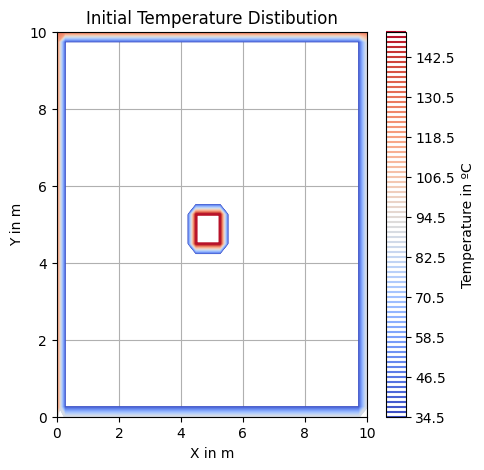

In [68]:
##plot Initial condition
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot()
ax.set_title("Initial Temperature Distibution")
ax.set_xlabel("X in m")
ax.set_ylabel("Y in m")
ax.grid(True)

contour=ax.contour(X,Y,T,levels=100,cmap="coolwarm")
cbar=fig.colorbar(contour,ax=ax)
cbar.set_label("Temperature in ºC")
plt.show()

In [69]:
## solve the equation transient state
for t in range(0,int(simulation_time/del_t)):
    for i in range(1,nx-1):
        for j in range(1,ny-1):
            t_next= T_previous[i][j]+ ((alpha*del_t)/(del_x**2))*(T_current[i+1,j] - 2*T_current[i,j] +T_current[i-1,j]) + ((alpha*del_t)/(del_y**2))*(T_current[i,j+1] - 2*T_current[i,j] +T_current[i,j-1]) 
            T_next[i][j]=t_next
    
    T_current=T_next.copy()
    T_previous=T_current.copy()
    T_final.append(T_current)

In [70]:
len (T_final) 

126

  0% (0 of 126) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (1 of 126) |                        | Elapsed Time: 0:00:00 ETA:   0:00:22
  1% (2 of 126) |                        | Elapsed Time: 0:00:00 ETA:   0:00:18
  2% (3 of 126) |                        | Elapsed Time: 0:00:00 ETA:   0:00:17
  3% (4 of 126) |                        | Elapsed Time: 0:00:00 ETA:   0:00:17
  3% (5 of 126) |                        | Elapsed Time: 0:00:00 ETA:   0:00:18
  4% (6 of 126) |#                       | Elapsed Time: 0:00:00 ETA:   0:00:18
  5% (7 of 126) |#                       | Elapsed Time: 0:00:01 ETA:   0:00:19
  6% (8 of 126) |#                       | Elapsed Time: 0:00:01 ETA:   0:00:20
  7% (9 of 126) |#                       | Elapsed Time: 0:00:01 ETA:   0:00:21
  7% (10 of 126) |#                      | Elapsed Time: 0:00:01 ETA:   0:00:22
  8% (11 of 126) |##                     | Elapsed Time: 0:00:02 ETA:   0:00:23
  9% (12 of 126) |##                    

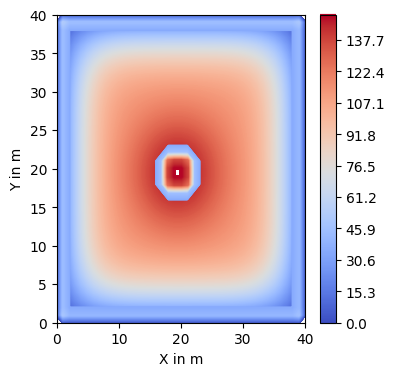

In [71]:
## animate the 
import progressbar
bar=progressbar.ProgressBar(max_value=len(T_final)).start()
fig1=plt.figure(figsize=(4,4))
ax1=fig1.add_subplot()
ax1.set_xlabel("X in m")
ax1.set_ylabel("Y in m")
contour1=ax1.contour(T_final[0],levels=500,cmap="coolwarm")
cbar1=fig1.colorbar(contour1,ax=ax1)
cbar.set_label("temperature in  ºC")
def animate(i):
    contour1=ax1.contour(T_final[i],levels=500,cmap="coolwarm")
    bar.update(i)
    return contour1
anim=animation.FuncAnimation(fig1,animate,frames=int(simulation_time/del_t))
writer=animation.FFMpegWriter(fps=(10))
anim.save("Temperature_distribution.mp4",writer=writer)